# 1. Import CellRefiner and packages

In [2]:
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc
import cellrefiner as cr

# 2. Load Data

The source data of human SCC Visium and scRNA-seq datasets can be found at the NCBI Gene Expression Omnibus (GEO) under accession GSE144240.

Citation: 	Ji AL, et al. Multimodal Analysis of Composition and Spatial Architecture in Human Squamous Cell Carcinoma. Cell 2020 Jul 23;182(2):497-514.e22

The preproceed datasets `Human_SCC_ST.h5ad` and `Human_SCC_SC.h5ad` can be download from [dropbox](https://www.dropbox.com/scl/fo/p8clpuy8q2eabofxj0mll/AM9nZvS39lE8LyVhCh5rD-4?rlkey=jq339e6umrgarzyn1caweilcv&st=ct9apur0&dl=0)

In [3]:
adata_st = sc.read_h5ad(f'data/Human_SCC_ST.h5ad')
adata_sc = sc.read_h5ad(f'data/Human_SCC_SC.h5ad')

cluster_key_st = 'leiden'
cluster_key_sc = 'level2_celltype'
spatial_key = 'spatial'
# remove Multiplet
exclude_types = ['Multiplet']
I = ~adata_sc.obs[cluster_key_sc].isin(exclude_types)
#  only select tumor sample
I = I & (adata_sc.obs['tum.norm']=='Tumor') 
adata_sc = adata_sc[I].copy()
print('SC:\n',adata_sc)
print('ST:\n',adata_st)

SC:
 AnnData object with n_obs × n_vars = 25506 × 24542
    obs: 'nCount_RNA', 'nFeature_RNA', 'patient', 'tum.norm', 'level1_celltype', 'level2_celltype', 'level3_celltype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'level2_celltype_colors', 'log1p', 'neighbors', 'patient_colors', 'pca', 'tum.norm_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
ST:
 AnnData object with n_obs × n_vars = 646 × 14990
    obs: 'n_genes', 'leiden'
    var: 'n_cells'
    uns: 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


# 3. Run cellrefiner cell to spot mapping and spatial refinement 

Load the ligand-receptor database sourced from CellChat

In [11]:
db_lr = cr.pp.ligand_receptor_database(species='human')
adata_cr = cr.pp.spatial_mapping(adata_st,adata_sc,db_lr,cluster_key_sc = cluster_key_sc)
print(adata_cr)

/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/numpy/linalg/_linalg.py:2371: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)


/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


GPU acceleration available with CuPy
AnnData object with n_obs × n_vars = 3230 × 24542
    obs: 'nCount_RNA', 'nFeature_RNA', 'patient', 'tum.norm', 'level1_celltype', 'level2_celltype', 'level3_celltype', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'level2_celltype_colors', 'log1p', 'neighbors', 'patient_colors', 'pca', 'tum.norm_colors', 'umap', 'rank_genes_groups', 'spatial_mapping'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


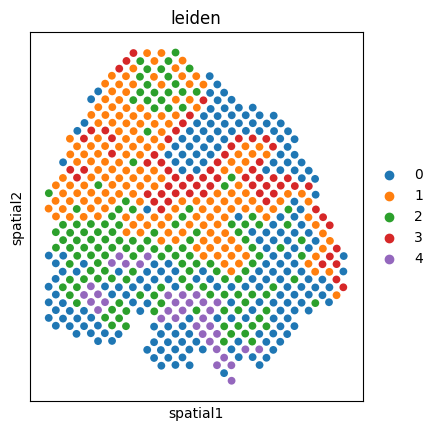

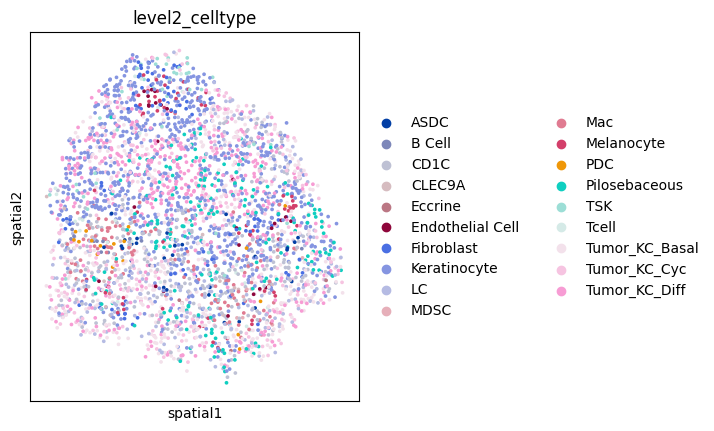

In [12]:
sc.pl.spatial(adata_st, color = cluster_key_st,spot_size = 200)
sc.pl.spatial(adata_cr, color = cluster_key_sc,spot_size = 100)

# 4. Cell shape modeling

In [14]:
sem = cr.tl.cell_shape_modeling(adata_cr,cluster_key = cluster_key_sc)

Simulation: 100%|██████████| 2000/2000 [01:30<00:00, 22.05it/s]


add .obsp['contacts'], .uns['contacts']
Computing alpha-shape with parameters: alpha=None, ns=10, r=1.2


Processing Cell Shapes: 100%|██████████| 3230/3230 [00:28<00:00, 112.56it/s]


<Axes: >

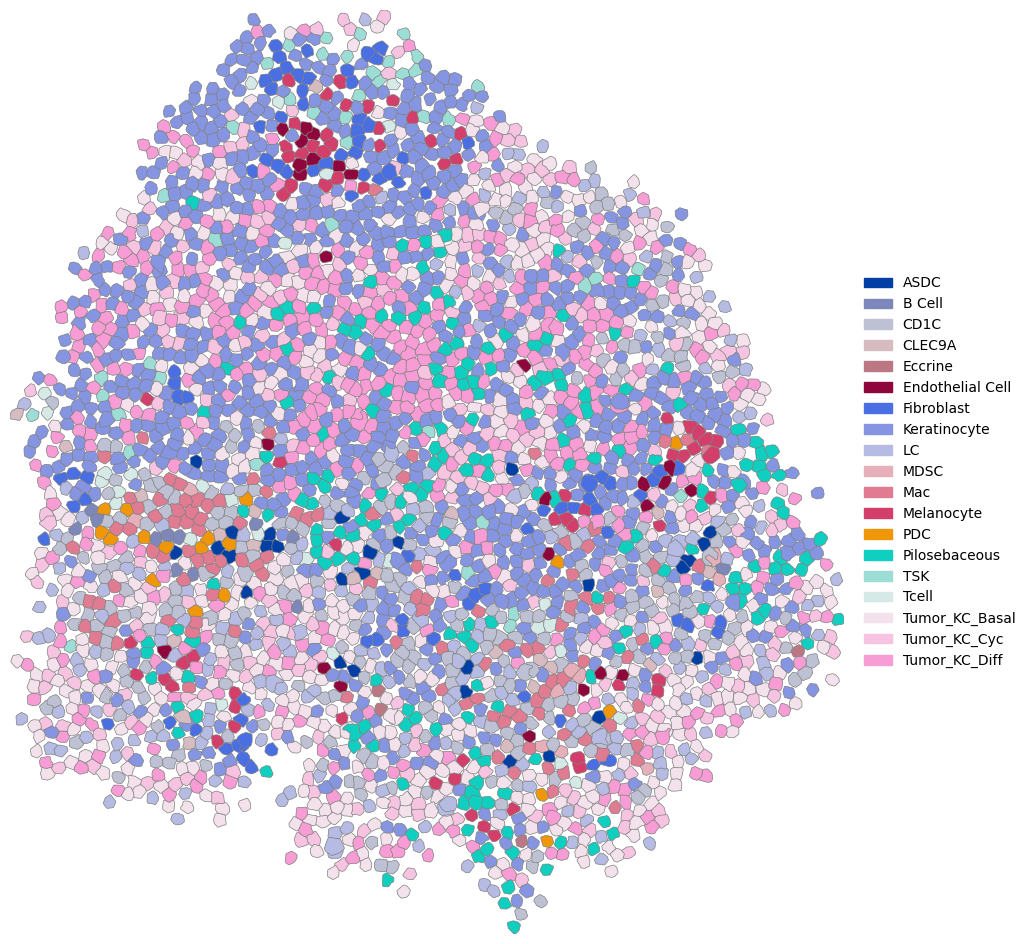

In [15]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5)

# 5. Contact-based communication analysis

In [16]:
db_lr = cr.pp.ligand_receptor_database(species='human', signaling_types='Cell-Cell Contact')
db_lr = cr.pp.filter_lr_database(db_lr,adata_cr, min_cell_pct=0.01)
cr.tl.contact_communication(db_lr, adata = adata_cr)

add .uns['contact_signal_info']
add .obsm['sender_signal'], .obsm['receiver_signal']


<Axes: >

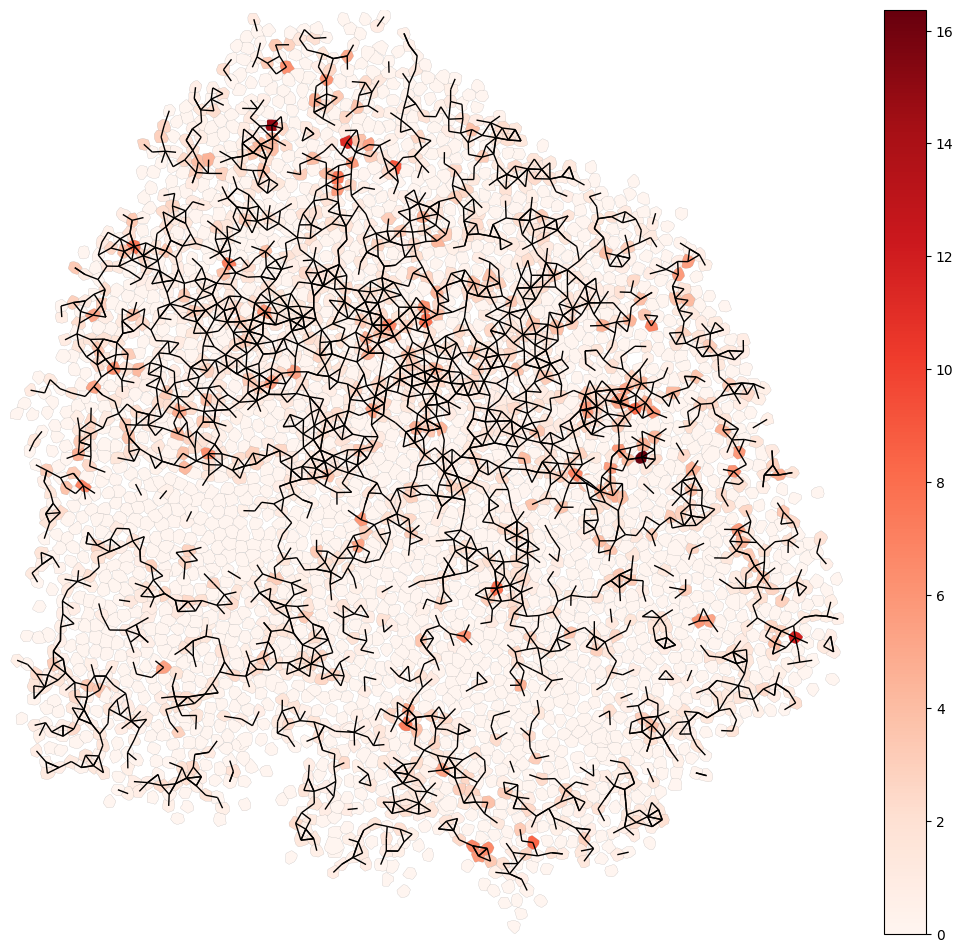

In [17]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,vis_key='NOTCH',boundary_color='gray',boundary_width=0.1)
cr.pl.plot_contact_signal(sem,ax=ax,signal = 'NOTCH')

Cluster-level communication

<Axes: >

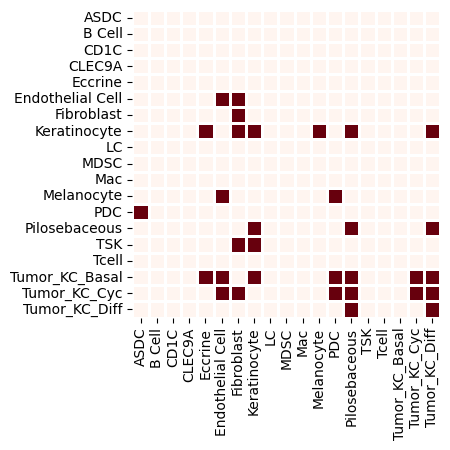

In [18]:
cr.tl.cluster_communication(adata_cr,cluster_key = cluster_key_sc,signal = 'NOTCH')
fig,ax=plt.subplots(figsize=(6,4))
sns.heatmap(adata_cr.uns[f'{cluster_key_sc}-NOTCH']['communication_pvalue']<0.05,square=True,linewidths=1,ax=ax,cmap='Reds',cbar=False)

# Visualize all contact-based communications

In [19]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5,save_name = 'cell_shape.png')
plt.close(fig)

# plot all pathway
summary = 'sender'
for pth in adata_cr.uns['contact_signal_info']['pathway']:
    fig,ax=plt.subplots(figsize=(12,12))
    if summary == 'cell':
        cr.pl.plot_cell_shape(sem,boundary_color='gray',boundary_width=0.4,ax=ax,enable_colorbar=False,enable_legend=True)
    else:
        cr.pl.plot_cell_shape(sem,vis_key=pth,summary=summary,boundary_color='gray',cmap_name='Reds',boundary_width=0.4,ax=ax,enable_colorbar=True)
    cr.pl.plot_contact_signal(sem,signal=pth,line_color = 'k', line_width=0.8, ax=ax, line_alpha=0.8)
    ax.set_axis_off()
    fig.savefig(f"{pth}_{summary}.png", dpi=500, bbox_inches='tight')
    plt.close(fig)

In [20]:
for sig_key in adata_cr.uns['contact_signal_info']['pathway']:
    cr.tl.cluster_communication(adata_cr,cluster_key_sc,sig_key)

In [21]:
# cluster-level
for pth in adata_cr.uns['contact_signal_info']['pathway']:
    fig,ax=plt.subplots(figsize=(6,4))
    sns.heatmap(adata_cr.uns[f'{cluster_key_sc}-{pth}']['communication_pvalue']<0.05,square=True,linewidths=1,ax=ax,cmap='Reds',cbar=False)
    fig.savefig(f"{pth}_significance.png", dpi=500, bbox_inches='tight')
    plt.close(fig)